# CNN Aumentada
## Grupo 2

### Importación de librerías

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Direcciones y etiquetas distintas.

In [2]:
TRAIN_DIR = Path('train')
TEST_DIR = Path('test')
ETIQUETAS = {'del': '.',
             'spa': '_',
             'not': ' '}

### Obteniendo rutas y etiquetas de las imágenes.

In [3]:
# Listado de rutas de imágenes.
imagenes_train = list(TRAIN_DIR.glob("*.jpg"))
nombres_imagenes = [str(texto).rsplit('\\', 1)[-1] for texto in imagenes_train]
nombres_imagenes[0:2]

['A1.jpg', 'A1001.jpg']

### Etiquetas de train.

In [4]:
etiquetas_train = []
for x in nombres_imagenes:
    if x[0:3] in ['del', 'spa', 'not']:
        etiquetas_train.append(ETIQUETAS[x[0:3]])
    else:
        etiquetas_train.append(x[0])
etiquetas_train = np.array(etiquetas_train)

rng = np.random.default_rng()
rng.choice(etiquetas_train, size=10, replace=False)

array(['Q', 'C', 'V', 'N', 'I', 'A', 'T', 'Q', 'J', 'D'], dtype='<U1')

### Eligiendo lotes balanceados.

In [5]:
# Semilla, tamaño de lote y generador de aleatorios.
seed = 42
batch_size = 290
rng = np.random.default_rng(seed)

# Etiquetas únicas
clases = np.unique(etiquetas_train)
n_por_clase = batch_size // len(clases)
n_batches = len(etiquetas_train) // batch_size

indices_clase = {c: np.where(etiquetas_train == c)[0] for c in clases}
lotes = []

for _ in range(n_batches):
    lote = []
    for c in clases:
        idx = indices_clase[c]
        seleccion = rng.choice(idx, size=n_por_clase, replace=len(idx) < n_por_clase)
        lote.extend(seleccion)
    rng.shuffle(lote)
    lotes.append(lote)

### Modelo.

In [6]:
DIM_IMAGEN = (64, 64)
N_CLASES = 29

modelo = Sequential([
    Input(shape=(*DIM_IMAGEN, 3)),
    Conv2D(64, 3, padding="same", activation="relu"),
    MaxPooling2D(2),
    Conv2D(128, 3, padding="same", activation="relu"),
    MaxPooling2D(2),
    Conv2D(256, 3, padding="same", activation="relu"),
    MaxPooling2D(2),
    Conv2D(512, 3, padding="same", activation="relu"),
    MaxPooling2D(2),
    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(N_CLASES, activation="softmax")
])

modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

### Transformador de imágenes.

In [7]:
seed = 0
rng = np.random.default_rng(seed)

augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=seed),
    tf.keras.layers.RandomRotation(0.08, seed=seed),
    tf.keras.layers.RandomZoom(0.1, seed=seed),
    tf.keras.layers.RandomTranslation(0.1, 0.1, seed=seed)
])

### Volviendo las clases numéricas.

In [8]:
class_to_idx = {c:i for i,c in enumerate(clases)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
train_labels = np.array([class_to_idx[x] for x in etiquetas_train], dtype=np.int32)

### Entrenando por lotes el modelo.

In [ ]:
EPOCHS = 4

for epoch in range(EPOCHS):

    # Imágenes que se modificarán.
    rng.shuffle(lotes)
    indices_aumentados_por_lote = []

    for indices_lote in lotes:

        # Elección de imágenes que se cambiarán.
        indices_lote = np.asarray(indices_lote)
        indices_aumentados = rng.choice(indices_lote, size=30, replace=False)
        indices_aumentados_por_lote.append(indices_aumentados.copy())

        # Imágenes del lote de entrenamiento.
        imagenes = []
        for i in indices_lote:
            img = tf.keras.utils.load_img(imagenes_train[i], target_size=DIM_IMAGEN)
            imagenes.append(tf.keras.utils.img_to_array(img))

        # Conjunto de entrenamiento original.
        X = np.asarray(imagenes, dtype=np.float32) / 255.0
        y = train_labels[indices_lote]

        # Conjunto de entrenamiento aumentado.
        posiciones = np.array([np.where(indices_lote == i)[0][0] for i in indices_aumentados])
        X_aug = augmentation(X[posiciones], training=True).numpy()
        y_aug = train_labels[indices_aumentados]

        X_batch = np.concatenate([X, X_aug], axis=0)
        y_batch = np.concatenate([y, y_aug], axis=0)

        resultado = modelo.train_on_batch(X_batch, y_batch)

### Conjunto de validación.

In [20]:
# Listado de rutas de imágenes.
imagenes_test = list(TEST_DIR.glob("*.jpg"))
nombres_imagenes_test = [str(texto).rsplit('\\', 1)[-1] for texto in imagenes_test]

# Etiquetas test
etiquetas_test = []
for x in nombres_imagenes_test:
    if x[0:3] in ['del', 'spa', 'not']:
        etiquetas_test.append(ETIQUETAS[x[0:3]])
    else:
        etiquetas_test.append(x[0])
etiquetas_test = np.array(etiquetas_test)
test_labels = np.array([class_to_idx[x] for x in etiquetas_test], dtype=np.int32)

imagenes_prueba = []
for i in imagenes_test:
    img = tf.keras.utils.load_img(i, target_size=DIM_IMAGEN)
    imagenes_prueba.append(tf.keras.utils.img_to_array(img))

X_test = np.asarray(imagenes_prueba, dtype=np.float32) / 255.0
y_test = test_labels


### Evaluación del modelo.

In [21]:
probabilidades = modelo.predict(X_test, verbose=0)
y_pred = np.argmax(probabilidades, axis=1)

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5919


### Matriz de confusión.

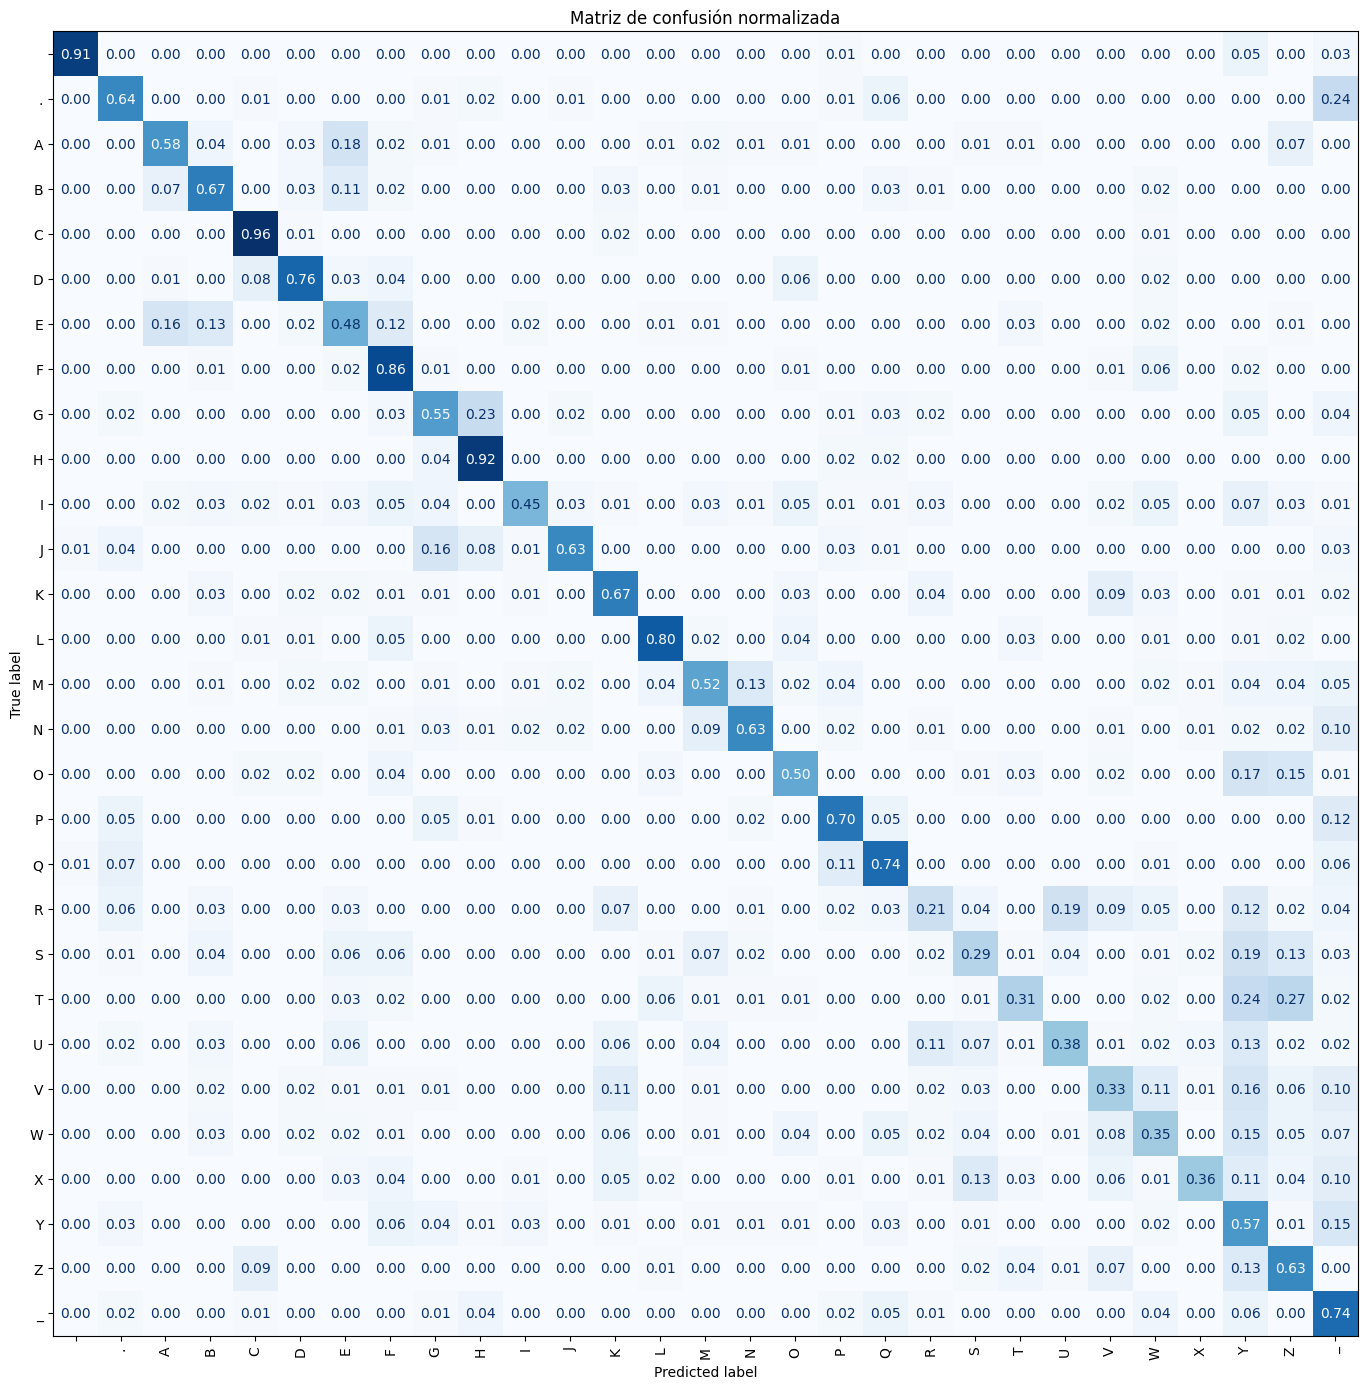

In [23]:
cm_norm = confusion_matrix(y_test, y_pred, labels=np.arange(29), normalize="true")
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=[idx_to_class[i] for i in range(29)])
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format=".2f", colorbar=False)
plt.title("Matriz de confusión normalizada")
plt.tight_layout()
plt.show()

Hay muchas letras o signos que son muy fáciles de identificar para la red.
De las que se pensaron en un inicio, se confundieron G, H y J; A y E.
Hay otras letras que se confunde como T, Y y Z; U, Y; entre otras. Estas no se identificaron y pueden haber aparecido por la aumentación de datos.

##### ¿Por qué un flip horizontal podría cambiar el significado de una seña en vez de solo aumentar los datos?
Porque en el lenguaje de señas la dirección de la mano y de los dedos, así como el dedo levantado, puede cambiar completamente el significado de la seña, por lo que cualquier cambio en la dirección, como un flip horizontal, puede hacer que el modelo considere que un pulgar se trata de un meñique y viceversa.

##### ¿Qué transformaciones sí tienen sentido para señas y cuáles no?
Hacer zoom, cambios de color, cambios en el ancho, cambios en el alto y rotaciones pequeñas.